# Opción 3: Amazon Athena

En esta sección usaremos **Amazon Athena** para crear y consultar una tabla **Apache Iceberg** registrada en el **AWS Glue Data Catalog**.

**Qué vas a hacer:**
- Configurar el *Query result location* (salida de resultados) en S3.
- Crear una base de datos en Athena.
- Crear una tabla Iceberg (tipo `iceberg`) apuntando a un `LOCATION` en S3.
- Consultar datos y explorar metadatos de Iceberg (por ejemplo, `$files` y `$history`).


## 1. Abrir Amazon Athena

1. En la consola de AWS, busca **Athena**.
2. En la pantalla de inicio, elige **Query your data with Trino SQL** y luego **Launch query editor**.


**Búsqueda de Athena en la consola**

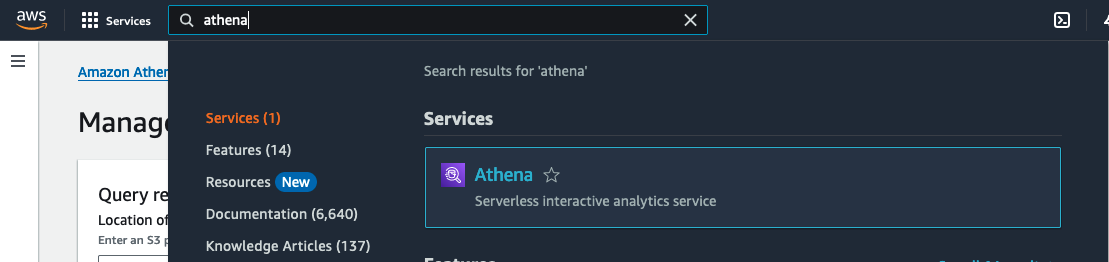


**Pantalla de inicio y acceso al Query editor**

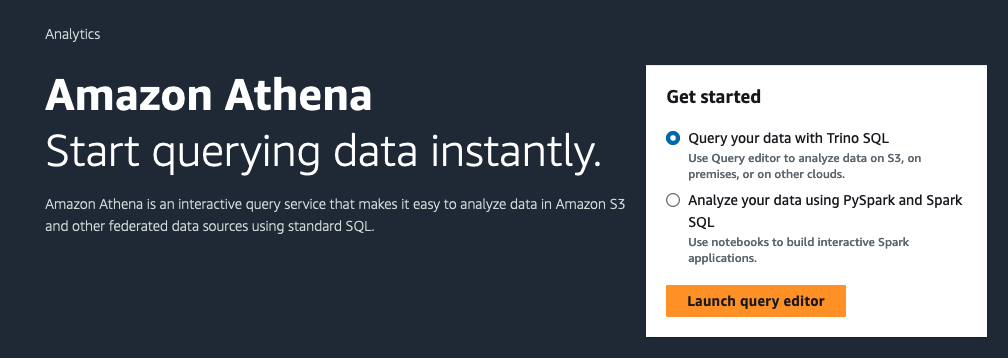


## 2. Configurar la ubicación de resultados de Athena (S3)

Antes de ejecutar tu primera consulta, Athena necesita un bucket o prefijo en S3 donde guardará los resultados.

- Ve a **Settings**.
- Define el **Query result location** con un prefijo similar a:

`s3://otfs-workshop-data-<your-account-id>/athena_res/`

Puntos de control:
- El bucket y la región deben coincidir con la región donde estás ejecutando Athena.
- Si usas Workgroups, revisa si el Workgroup sobrescribe la configuración de resultados.


**Aviso inicial para configurar el Query result location**

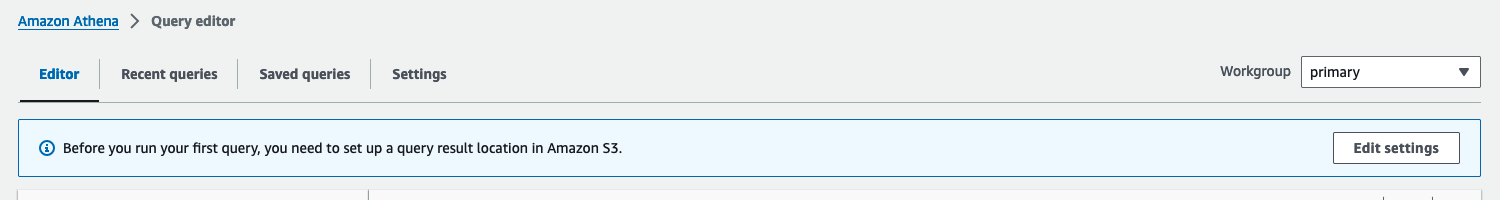


**Pestaña Settings en el editor de Athena**

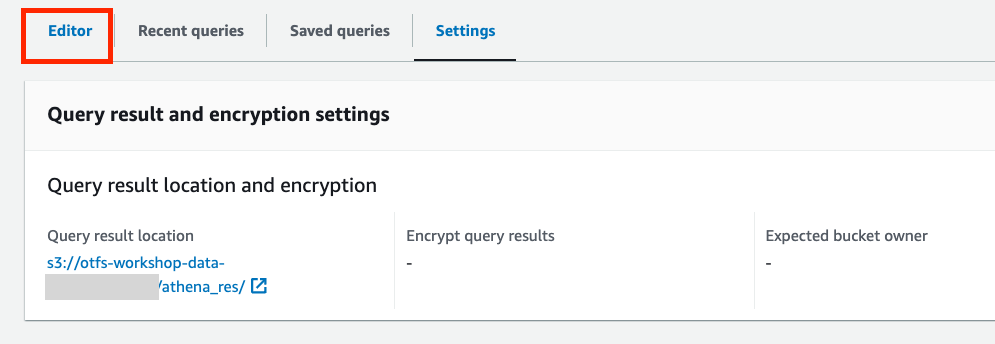


**Configuración del Query result location and encryption**

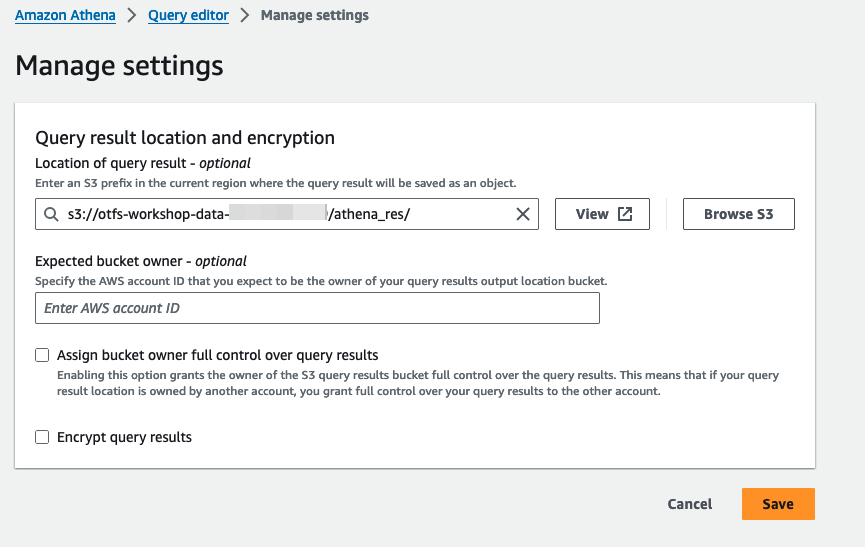


## 3. Crear la base de datos en Athena

Crea una base de datos en el catálogo **AwsDataCatalog**. Luego podrás seleccionarla en el panel izquierdo del editor.


In [ ]:
create database athena_iceberg_db;



**Creación de la base de datos en Athena**

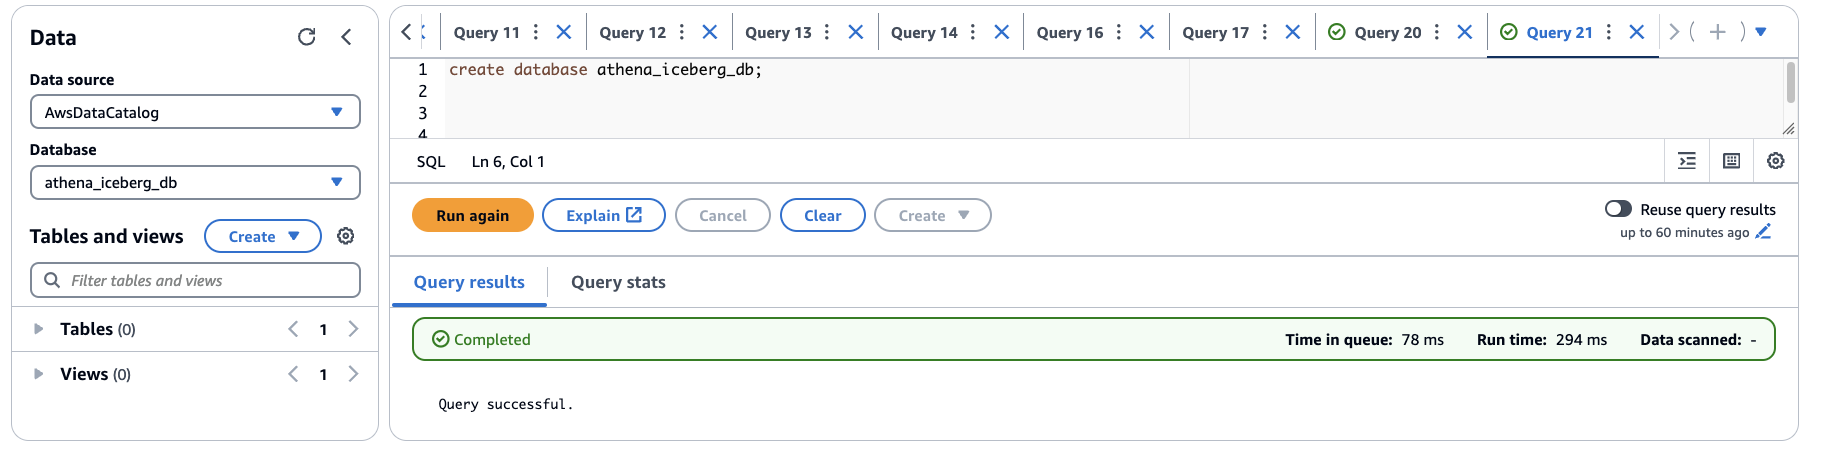


## 4. Crear la tabla Iceberg en Athena

Crea una tabla Iceberg apuntando a un `LOCATION` en S3.

Acciones requeridas:
- Reemplaza `<your-account-id>` por tu ID real si el workshop lo requiere.
- Asegura que el `LOCATION` exista y que Athena tenga permisos de escritura y lectura.


In [ ]:
CREATE TABLE athena_iceberg_db.customer_iceberg (
    c_customer_sk INT COMMENT 'unique id',
    c_customer_id STRING,
    c_first_name STRING,
    c_last_name STRING,
    c_email_address STRING)
LOCATION 's3://otfs-workshop-data-<your-account-id>/datasets/athena_iceberg/customer_iceberg'
TBLPROPERTIES (
    'table_type'='iceberg',
    'format'='PARQUET',
    'write_compression'='zstd'
);



**Creación de la tabla Iceberg en Athena**

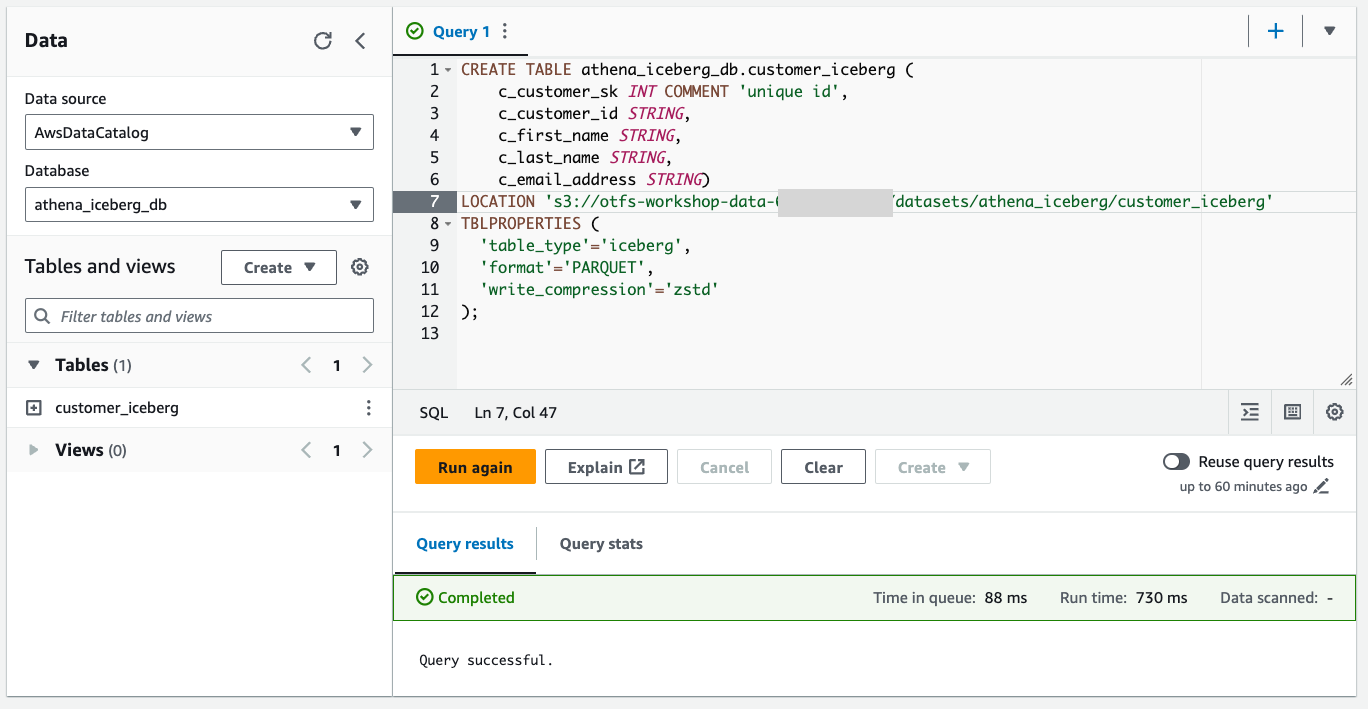


## 5. Validar la tabla

Puedes validar con:
- `SHOW TABLES` para listar tablas.
- `DESCRIBE` para revisar el esquema.


In [ ]:
SHOW TABLES IN athena_iceberg_db;



**Validación con SHOW TABLES**

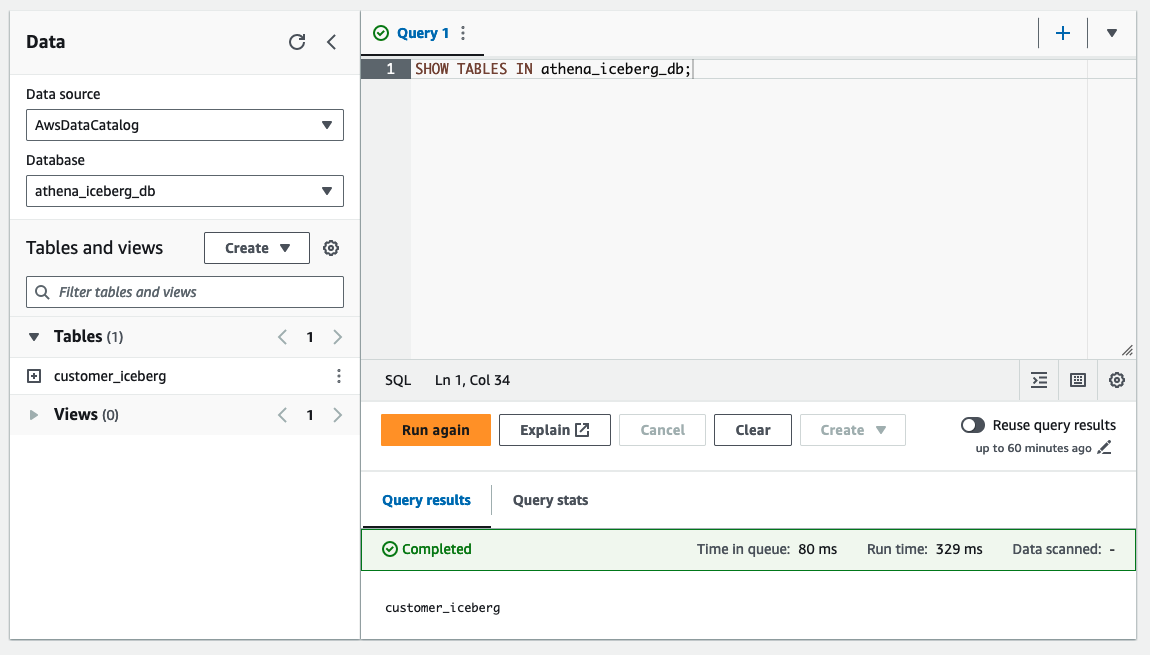


In [ ]:
DESCRIBE customer_iceberg;



**Validación con DESCRIBE**

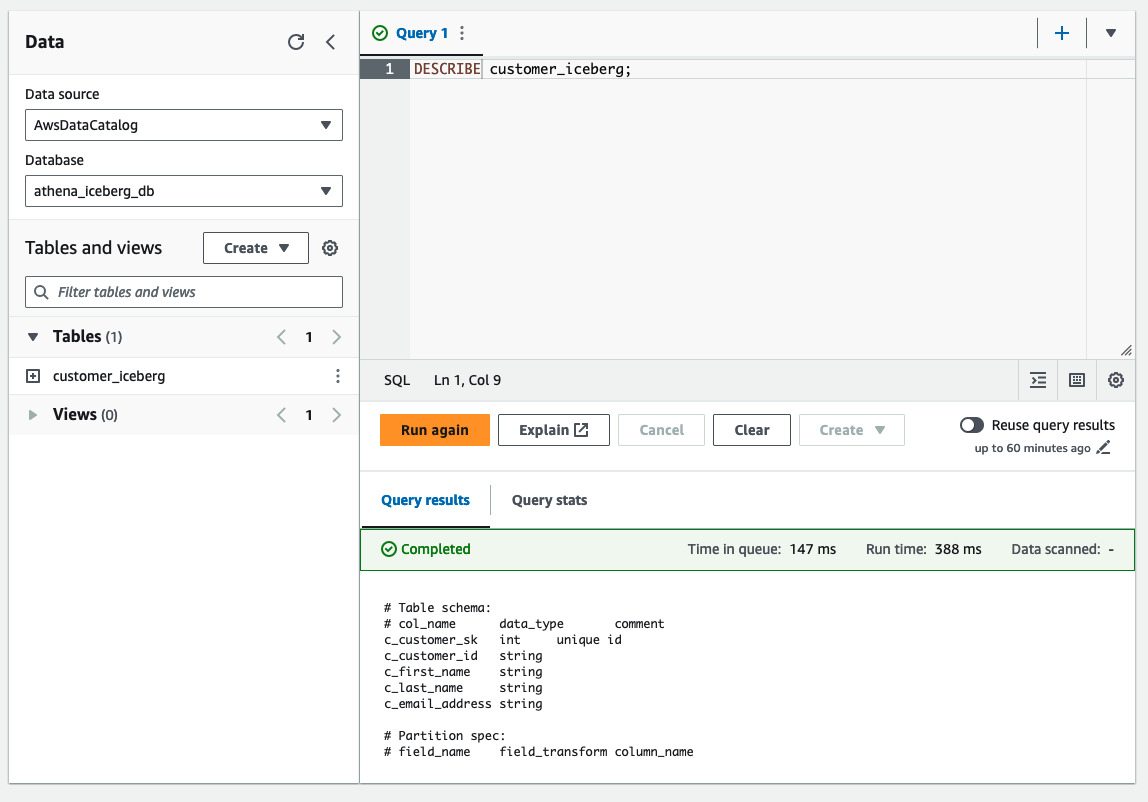


## 6. Insertar y consultar datos

En el workshop se inserta información desde una tabla de ejemplo (`tpcds.prepared_customer`) y luego se consulta una muestra con `LIMIT`.

Nota:
- La disponibilidad de `tpcds.prepared_customer` depende de cómo esté configurado el entorno del laboratorio.


In [ ]:
INSERT INTO athena_iceberg_db.customer_iceberg
SELECT * FROM tpcds.prepared_customer

select * from athena_iceberg_db.customer_iceberg limit 10;



**Insert y consulta de muestra con LIMIT**

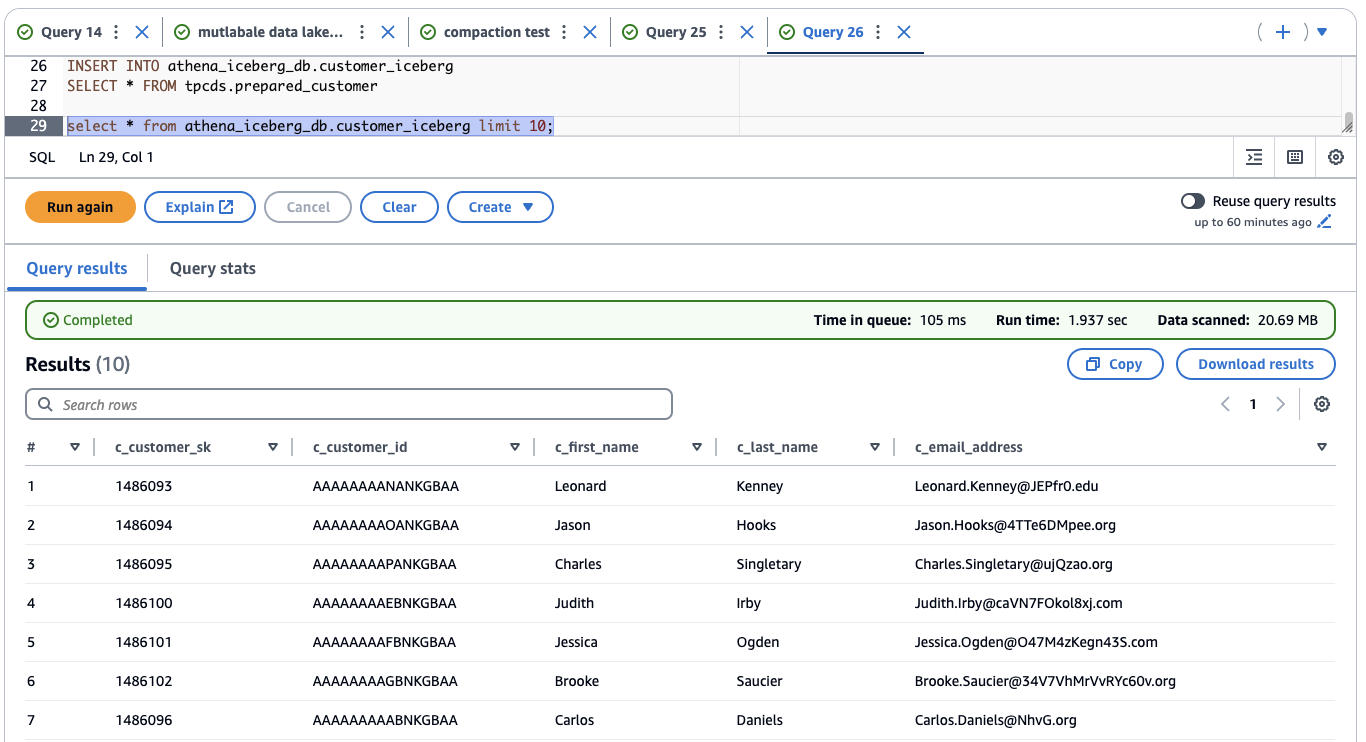


## 7. Explorar archivos físicos con tablas de metadatos

Iceberg expone tablas de metadatos que puedes consultar con Athena.  
Por ejemplo, `customer_iceberg$files` muestra los archivos de datos (por ejemplo, Parquet) que pertenecen a la tabla.

Si aún no hay datos, es posible que no veas resultados.


In [ ]:
SELECT * FROM "athena_iceberg_db"."customer_iceberg$files"



**Consulta de metadata table $files (sin resultados inicialmente)**

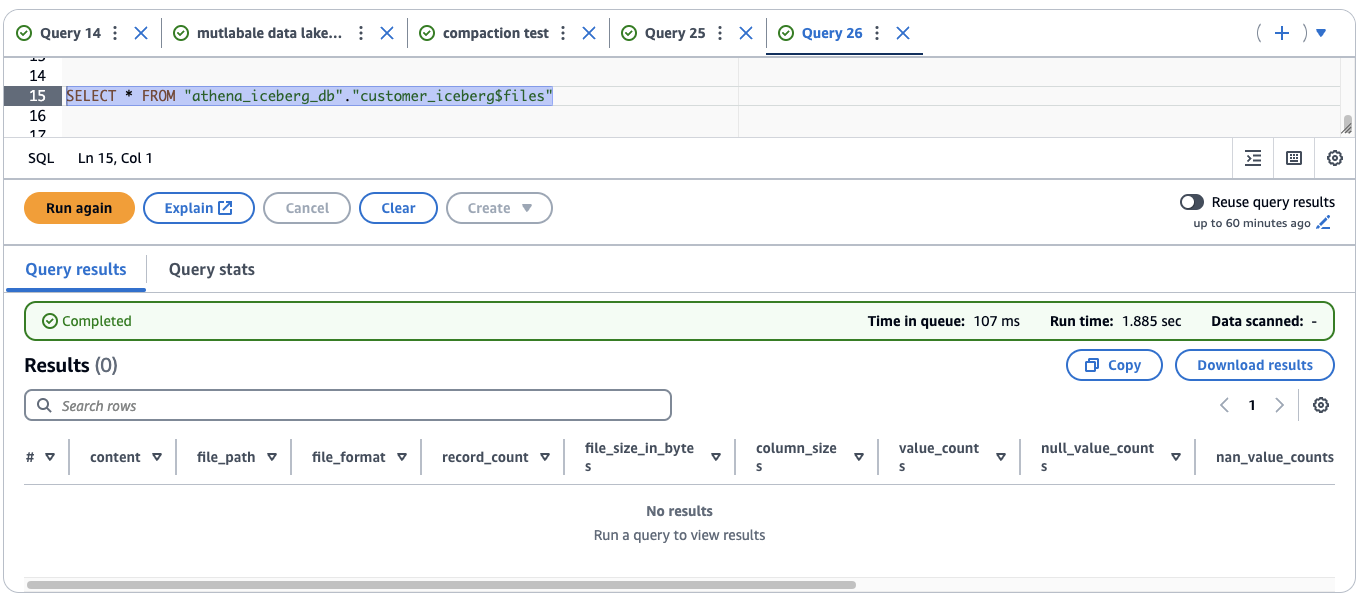


Después de insertar o modificar datos, deberías ver rutas de archivos Parquet en S3:




**Consulta $files mostrando rutas de archivos Parquet**

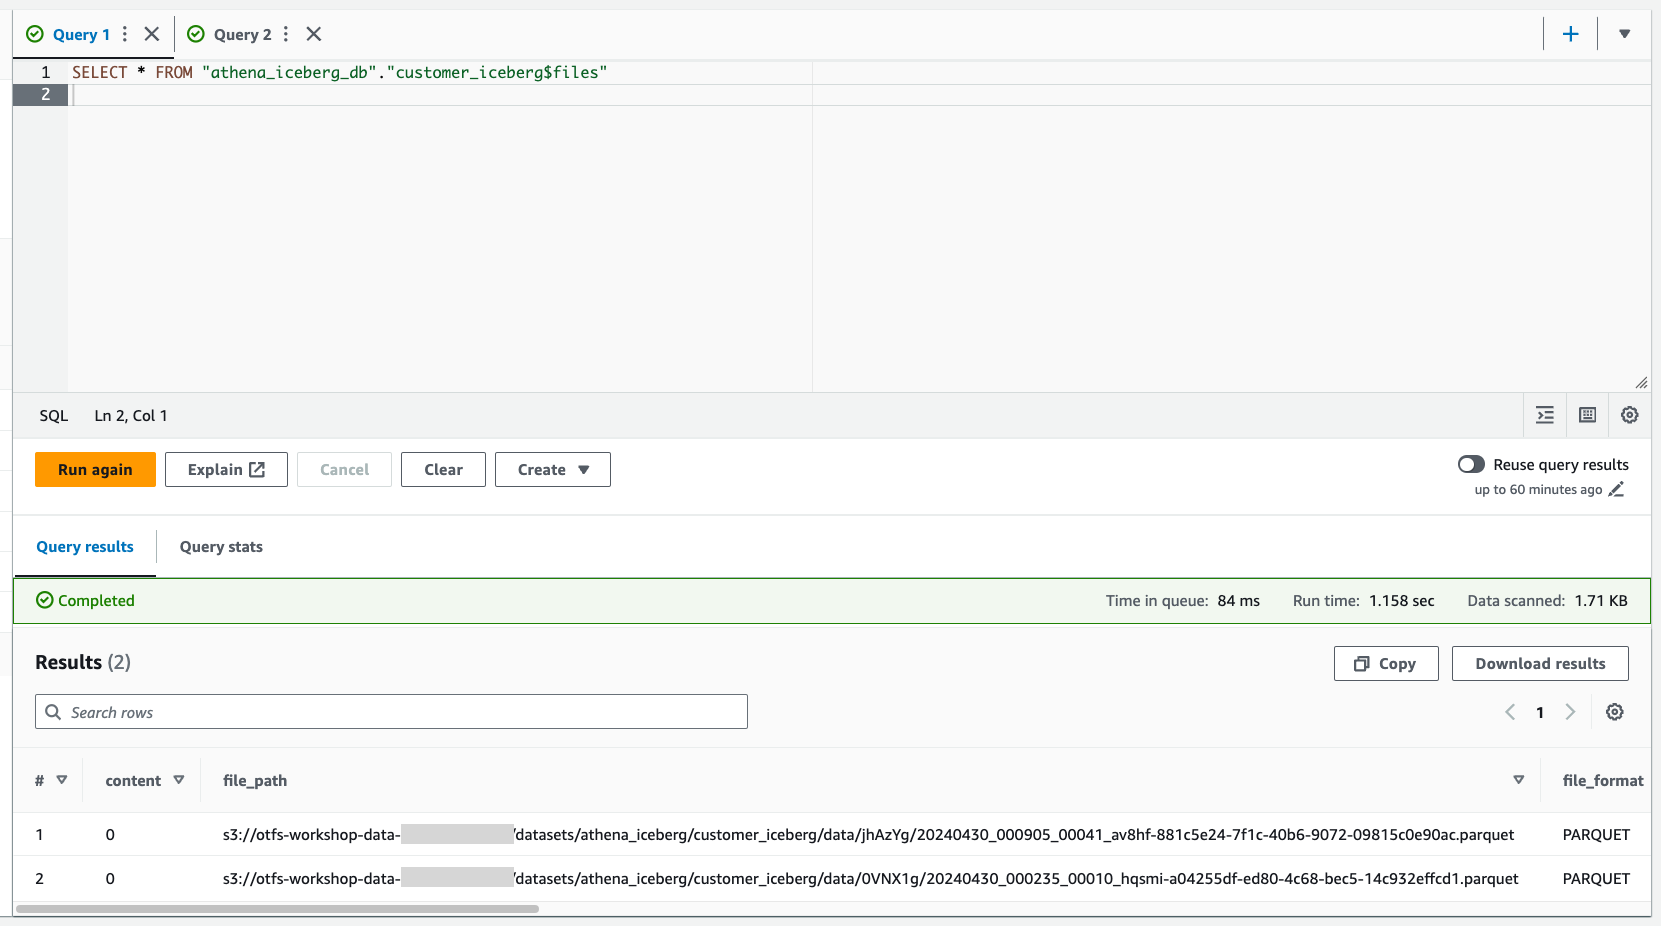


## 8. Revisar el historial de snapshots

La tabla `customer_iceberg$history` lista snapshots y su relación (padre/hijo).  
Es útil para auditar cambios y para entender *time travel*.


In [ ]:
SELECT * FROM "athena_iceberg_db"."customer_iceberg$history"
order by made_current_at;



**Consulta $history mostrando snapshots**

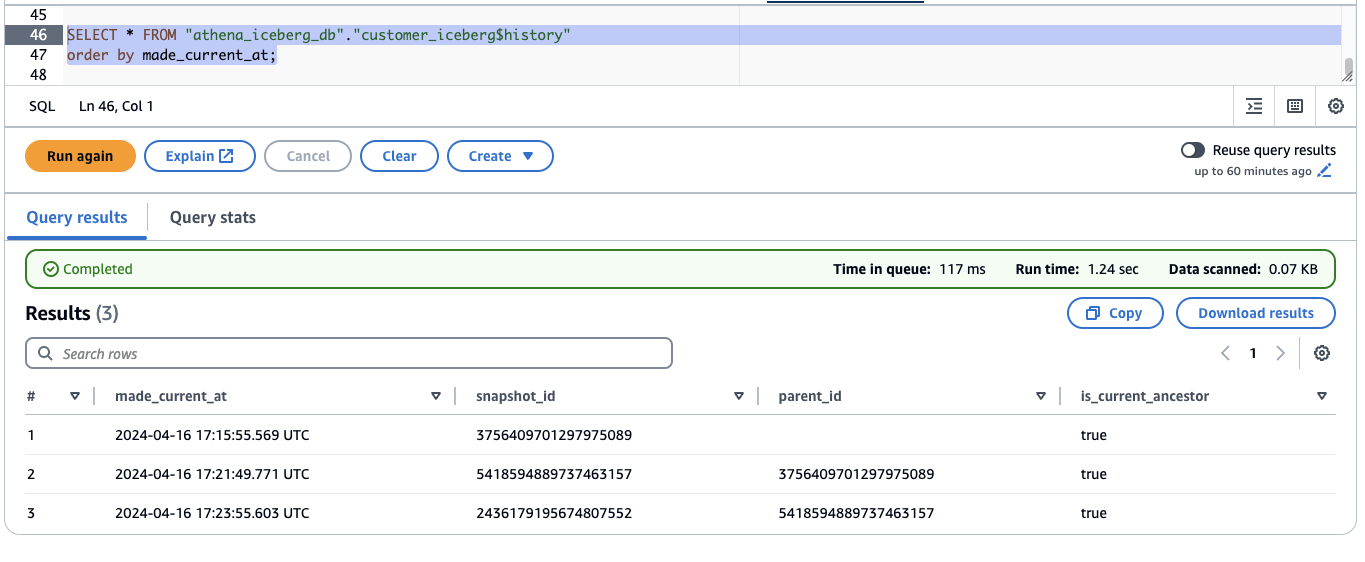


## 9. Ver la estructura en S3

En el `LOCATION` de la tabla Iceberg normalmente verás dos prefijos principales:

- **data/**: archivos de datos (por ejemplo, Parquet).
- **metadata/**: archivos JSON/Avro con metadatos, manifests, snapshots, etc.




**Prefijo data/ en S3**

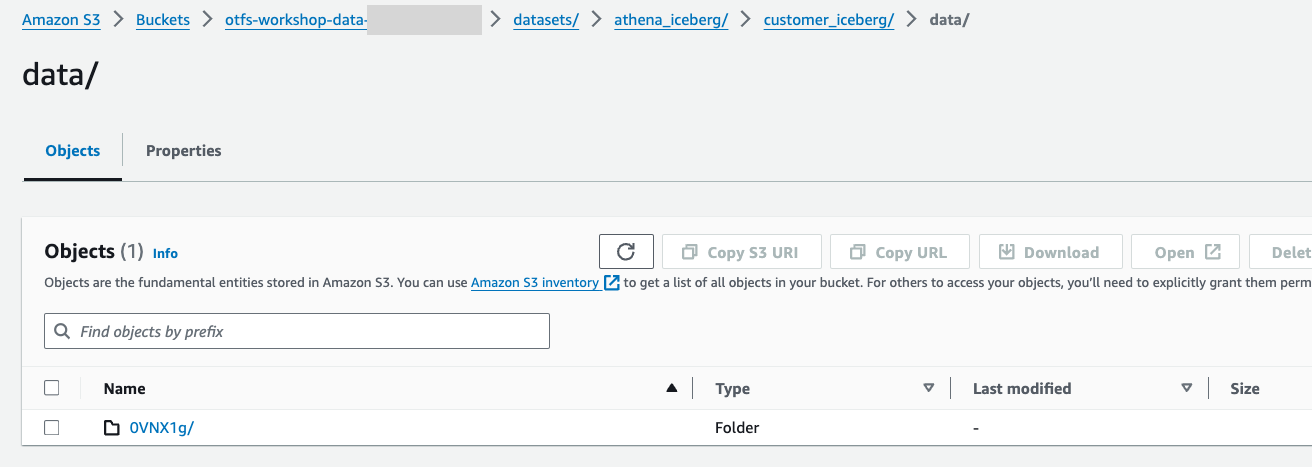




**Prefijo metadata/ en S3**

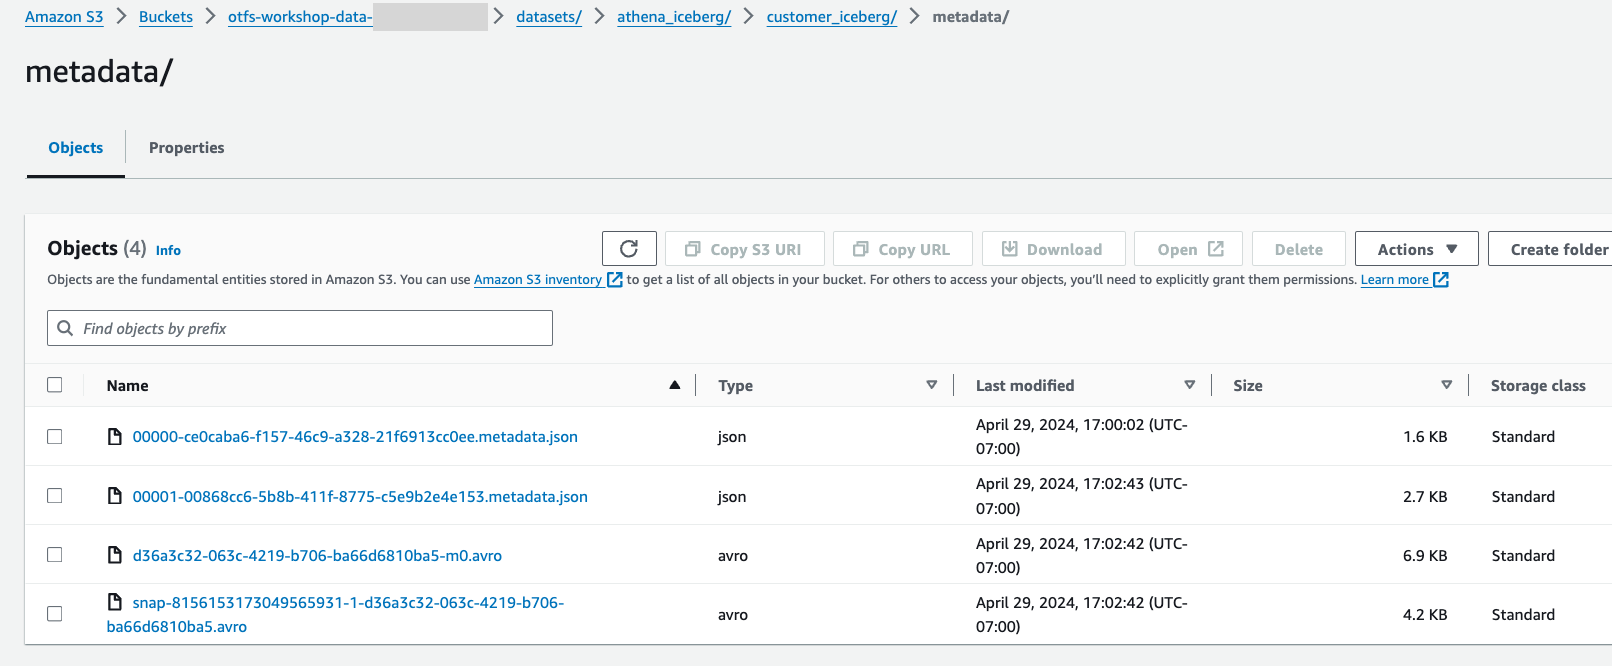


## 10. Modelo mental de Iceberg

A alto nivel:
- El catálogo (Glue y Athena) mantiene el puntero al archivo de metadatos actual.
- Cada commit crea una nueva instantánea (snapshot) y actualiza la referencia.
- Los manifests listan qué archivos de datos pertenecen a cada snapshot.




**Estructura subyacente de Iceberg**

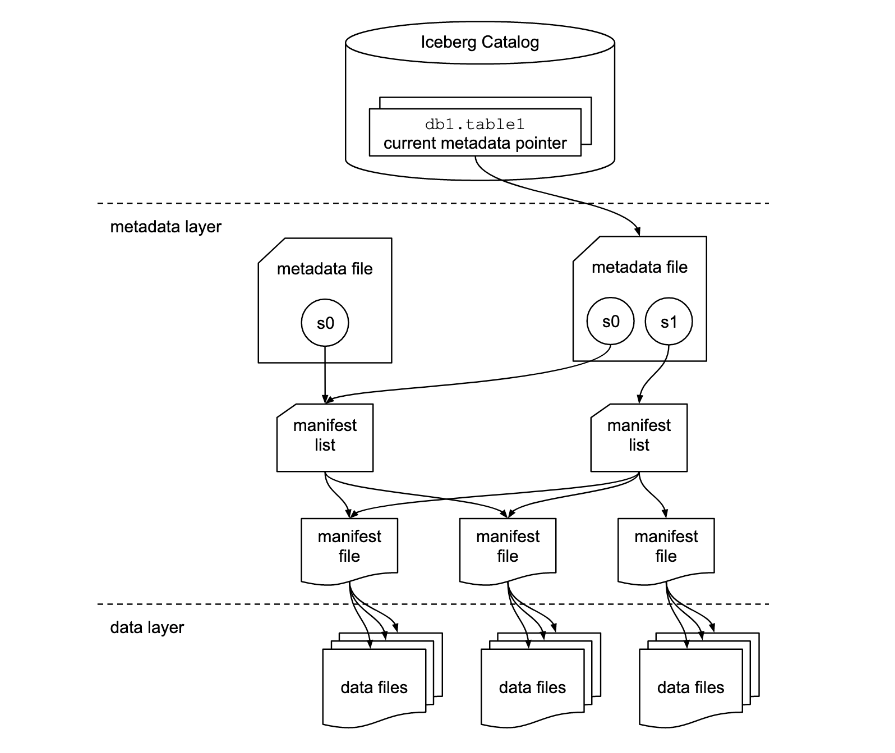
